In [2]:
import os
import sys; sys.path.append(os.path.abspath('..'))
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image

from src.environment import WarehouseEnv
from src.planning.fsm_planner import FSMAutomaton
from src.utils.visualization import EnvironmentVisualizer, create_evaluation_animation
import yaml
from src.utils.buffer import ReplayBuffer

with open("../config/warehouse_v1.yaml", 'r') as f:
    config = yaml.safe_load(f)
env = WarehouseEnv(config)
fsm = FSMAutomaton(start_pos = config['fsm']['start_state'], goal_pos = config['fsm']['goal_state'], config=config)

print(env.env_config)

nn_config = config['nn']
gen_config = config['data_gen']

buffer = ReplayBuffer(
    state_dim=nn_config['state_dim'],
    action_dim=nn_config['action_dim'],
    subgoal_dim=nn_config['subgoal_dim'],
    max_size=gen_config['num_transitions']
)

print(buffer.__len__())

{'workspace': [12.0, 10.0], 'dt': 0.1, 'v_max': 1.5, 'a_max': 3.0, 'omega_max': 1.57, 'robot_radius': 0.15}
0


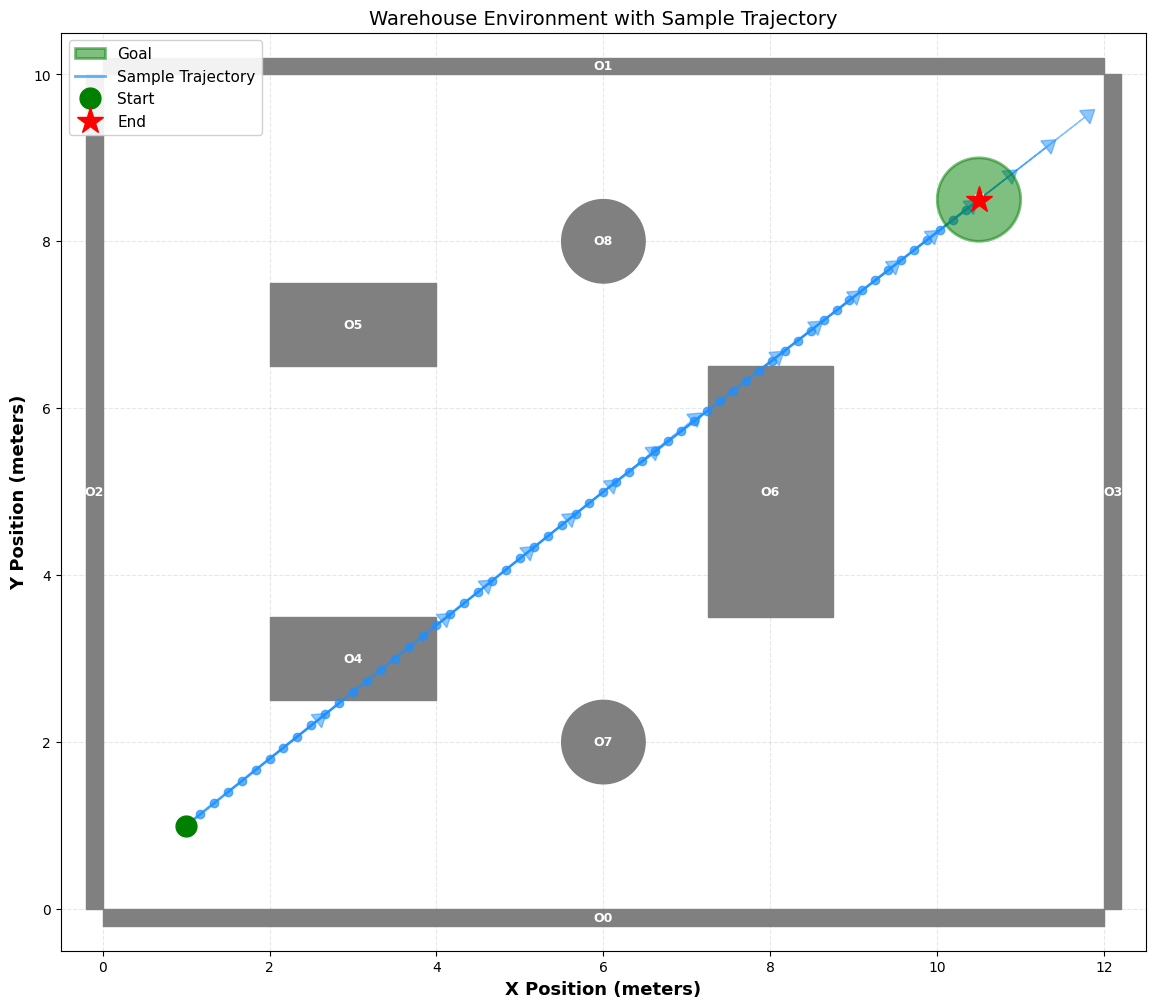

Creating evaluation animation at ../visualizations/sample_trajectory.gif...
... animation saved.


In [ ]:
# --- Test the trajectory visualizer and animation utilities ---
visualizer = EnvironmentVisualizer(env)

start_xy = np.array(config['fsm']['start_state'][:2], dtype=np.float32)
waypoint_xy = np.array([6.0, 5.0], dtype=np.float32)  # passes between first set of obstacles
goal_xy = np.array(config['fsm']['goal_state'][:2], dtype=np.float32)

segment_1 = np.linspace(start_xy, waypoint_xy, 30, endpoint=False)
segment_2 = np.linspace(waypoint_xy, goal_xy, 30)
path_points = np.vstack([segment_1, segment_2])

def build_states_from_points(points: np.ndarray) -> list:
    states = []
    for idx, point in enumerate(points):
        if idx < len(points) - 1:
            delta = points[idx + 1] - point
            heading = np.arctan2(delta[1], delta[0])
        else:
            heading = 0.0
        states.append(np.array([
            point[0],
            point[1],
            np.cos(heading),
            np.sin(heading),
            0.0
        ], dtype=np.float32))
    return states

sample_states = build_states_from_points(path_points)

fig, ax = visualizer.plot_environment(goal=config['fsm']['goal_state'])
visualizer.plot_trajectory(sample_states, ax=ax, color='dodgerblue', label='Sample Trajectory', show_arrows=True)
ax.set_title('Warehouse Environment with Sample Trajectory', fontsize=14)
plt.show()

# Create a quick GIF of the same path to ensure the animation helper works
traj_gif_path = "../visualizations/sample_trajectory.gif"
create_evaluation_animation(env, sample_states, config['fsm']['goal_state'], traj_gif_path)
Image(filename=traj_gif_path)
